In [14]:

import os
import pandas as pd
from collections import defaultdict

guide_file = "01_make_simulations_output/guides.txt"
sample_file = "01_make_simulations_output/samples.txt"
aggregated_stats_file = "02_run_output/aggregated_stats_all.txt"

samples = pd.read_csv(sample_file, sep="\t")
samples

,Name,r1,Group,background_noise_rate,replicate
0,sample_0_edited_0_noise_rep0,01_make_simulations_output/sample_0_edited_0_n...,edited,0.00,0
1,sample_1_unedited_0_noise_rep0,01_make_simulations_output/sample_1_unedited_0...,unedited,0.00,0
2,sample_2_edited_0.01_noise_rep0,01_make_simulations_output/sample_2_edited_0.0...,edited,0.01,0
3,sample_3_unedited_0.01_noise_rep0,01_make_simulations_output/sample_3_unedited_0...,unedited,0.01,0
4,sample_4_edited_0.05_noise_rep0,01_make_simulations_output/sample_4_edited_0.0...,edited,0.05,0
5,sample_5_unedited_0.05_noise_rep0,01_make_simulations_output/sample_5_unedited_0...,unedited,0.05,0
6,sample_6_edited_0.1_noise_rep0,01_make_simulations_output/sample_6_edited_0.1...,edited,0.10,0
7,sample_7_unedited_0.1_noise_rep0,01_make_simulations_output/sample_7_unedited_0...,unedited,0.10,0
8,sample_8_edited_0_noise_rep1,01_make_simulations_output/sample_8_edited_0_n...,edited,0.00,1
9,sample_9_unedited_0_noise_rep1,01_make_simulations_output/sample_9_unedited_0...,unedited,0.00,1


In [ ]:
background_mutation_rates = sorted([float(x) for x in samples['background_noise_rate'].unique()])

replicate_counts = [3,5]

output_folder = "03_make_replots.ipynb.output"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

sig_tests = [("hard_cutoff","hard_cutoff,1"),
             ("mean_diff","mean_diff,edited,unedited,0.01"),
             ("t_test","t_test,edited,unedited,0.05"),
             ("mann_whitney","mann_whitney,edited,unedited,0.05"),
             ("neg_binomial","neg_binomial,edited,unedited,0.05")]

command_file = os.path.join(output_folder, "commands.txt")
sig_test_outputs = defaultdict(list)
with open(command_file, 'w') as f:
    for replicate_number in replicate_counts:
        rep_samples = samples[samples['replicate'] < replicate_number]
        for background_mutation_rate in background_mutation_rates:
            edited_samples = [x for x in rep_samples['Name'] if f"_edited_{background_mutation_rate}_noise" in x]
            unedited_samples = [x for x in rep_samples['Name'] if f"_unedited_{background_mutation_rate}_noise" in x]
            sub_sample_file = os.path.join(output_folder, f"noise_{background_mutation_rate}_reps_{replicate_number}.agg_samples.txt")
            with open(sub_sample_file, 'w') as bg_f:
                bg_f.write("Name\tfastq_r1\tGroup\n")
                for sample in edited_samples:
                    bg_f.write(f'{sample}\t{samples.loc[samples["Name"] == sample, "r1"].values[0]}\tedited\n')
                for sample in unedited_samples:
                    bg_f.write(f'{sample}\t{samples.loc[samples["Name"] == sample, "r1"].values[0]}\tunedited\n')
            f.write(f'CRISPRessoSea Replot --reordered_stats_file {aggregated_stats_file} --reordered_sample_file {sub_sample_file} --output_folder {output_folder}/noise_{background_mutation_rate}_reps_{replicate_number}\n')
            for sig_test_name, sig_test_string in sig_tests:
                test_output_folder = os.path.join(output_folder, f"noise_{background_mutation_rate}_reps_{replicate_number}_{sig_test_name}")
                f.write(f'CRISPRessoSea Replot --reordered_stats_file {aggregated_stats_file} --reordered_sample_file {sub_sample_file} --output_folder {test_output_folder} --sig_method_parameters {sig_test_string}\n')
                sig_test_outputs[sig_test_name].append(test_output_folder)

[0.0, 0.01, 0.05, 0.1]


In [11]:
aggregated_stats = pd.read_csv(aggregated_stats_file, sep="\t").copy()
aggregated_stats["editing_rate"] = aggregated_stats["target_name"].str.split("EditingRate").str[-1].astype(float)
samples = samples.copy()
samples["noise_rate_label"] = samples["Name"].str.extract(r"_(?:edited|unedited)_([^_]+)_noise")

hard_cutoff_string = dict(sig_tests)["hard_cutoff"]
hard_cutoff_threshold = float(hard_cutoff_string.split(",")[1])
hard_cutoff_pct = hard_cutoff_threshold if hard_cutoff_threshold > 1 else hard_cutoff_threshold

sig_test_summary_tables = {}

for sig_test_name, test_output_folders in sig_test_outputs.items():
    summary_rows = []

    for test_output_folder in test_output_folders:
        background_noise_label = test_output_folder.split("noise_")[-1].split("_")[0]
        background_noise_rate = float(background_noise_label)

        if sig_test_name == "hard_cutoff":
            edited_samples = [
                sample_name
                for sample_name in samples.loc[
                    (samples["noise_rate_label"] == background_noise_label)
                    & samples["Name"].str.contains("_edited_"),
                    "Name",
                ]
            ]
            unedited_samples = [
                sample_name
                for sample_name in samples.loc[
                    (samples["noise_rate_label"] == background_noise_label)
                    & samples["Name"].str.contains("_unedited_"),
                    "Name",
                ]
            ]

            edited_cols = [f"{sample_name}_mod_pct" for sample_name in edited_samples]
            unedited_cols = [f"{sample_name}_mod_pct" for sample_name in unedited_samples]

            hard_cutoff_df = aggregated_stats[["target_name", "target_id", "editing_rate"] + edited_cols + unedited_cols].copy()
            hard_cutoff_df["background_noise_rate"] = background_noise_rate
            hard_cutoff_df["edited_significant_n"] = (hard_cutoff_df[edited_cols] >= hard_cutoff_pct).sum(axis=1)
            hard_cutoff_df["unedited_significant_n"] = (hard_cutoff_df[unedited_cols] >= hard_cutoff_pct).sum(axis=1)
            hard_cutoff_df["pvalue"] = pd.NA
            hard_cutoff_df["significant"] = pd.NA

            summary_rows.append(
                hard_cutoff_df[[
                    "target_name",
                    "target_id",
                    "editing_rate",
                    "background_noise_rate",
                    "edited_significant_n",
                    "unedited_significant_n",
                    "pvalue",
                    "significant",
                ]]
            )
            continue

        p_value_file = os.path.join(test_output_folder, "CRISPRessoSea_all_mod_pct.p_values.txt")
        if not os.path.exists(p_value_file):
            print(f"Skipping missing file: {p_value_file}")
            continue

        p_value_df = pd.read_csv(p_value_file, sep="\t")
        p_value_df["editing_rate"] = p_value_df["target_name"].str.split("EditingRate").str[-1].astype(float)
        p_value_df["background_noise_rate"] = background_noise_rate
        p_value_df["pvalue"] = p_value_df["p_val"] if "p_val" in p_value_df.columns else pd.NA
        p_value_df["edited_significant_n"] = pd.NA
        p_value_df["unedited_significant_n"] = pd.NA

        summary_rows.append(
            p_value_df[[
                "target_name",
                "target_id",
                "editing_rate",
                "background_noise_rate",
                "edited_significant_n",
                "unedited_significant_n",
                "pvalue",
                "significant",
            ]]
        )

    sig_test_summary_tables[sig_test_name] = pd.concat(summary_rows, ignore_index=True).sort_values(
        ["background_noise_rate", "editing_rate"]
    )
    sig_test_summary_tables[sig_test_name].to_csv(
        os.path.join(output_folder, f"{sig_test_name}.aggregated_significance.tsv"),
        sep="\t",
        index=False,
    )

sig_test_summary_tables["hard_cutoff"].head()


,target_name,target_id,editing_rate,background_noise_rate,edited_significant_n,unedited_significant_n,pvalue,significant
9,Guide9_EditingRate1e-06,9_guide9_ON,0.000001,0.0,0,0,NaN,NaN
8,Guide8_EditingRate1e-05,8_guide8_ON,0.000010,0.0,0,0,NaN,NaN
7,Guide7_EditingRate0.0001,7_guide7_ON,0.000100,0.0,2,0,NaN,NaN
6,Guide6_EditingRate0.001,6_guide6_ON,0.001000,0.0,3,0,NaN,NaN
5,Guide5_EditingRate0.01,5_guide5_ON,0.010000,0.0,3,0,NaN,NaN


In [12]:
{sig_test_name: df.head() for sig_test_name, df in sig_test_summary_tables.items()}


{'hard_cutoff':                 target_name    target_id  editing_rate  background_noise_rate  \
 9   Guide9_EditingRate1e-06  9_guide9_ON      0.000001                    0.0   
 8   Guide8_EditingRate1e-05  8_guide8_ON      0.000010                    0.0   
 7  Guide7_EditingRate0.0001  7_guide7_ON      0.000100                    0.0   
 6   Guide6_EditingRate0.001  6_guide6_ON      0.001000                    0.0   
 5    Guide5_EditingRate0.01  5_guide5_ON      0.010000                    0.0   
 
    edited_significant_n  unedited_significant_n pvalue significant  
 9                     0                       0    NaN         NaN  
 8                     0                       0    NaN         NaN  
 7                     2                       0    NaN         NaN  
 6                     3                       0    NaN         NaN  
 5                     3                       0    NaN         NaN  ,
 'mean_diff':                 target_name    target_id  editing_rate  

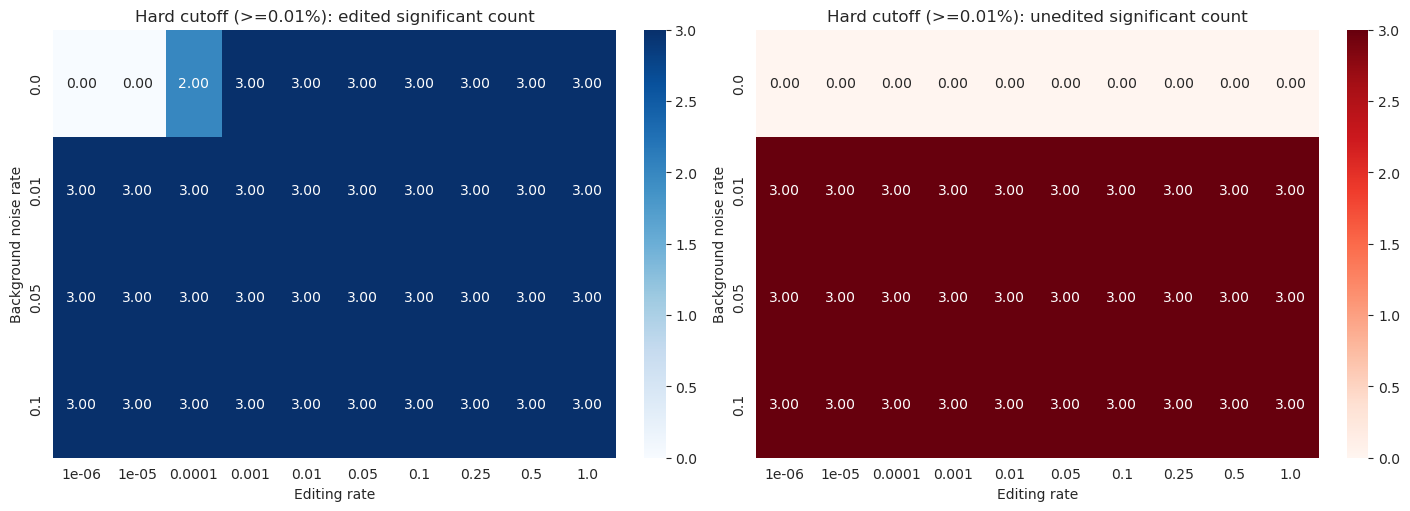

/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/envs/kc_crispresso/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/envs/kc_crispresso/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


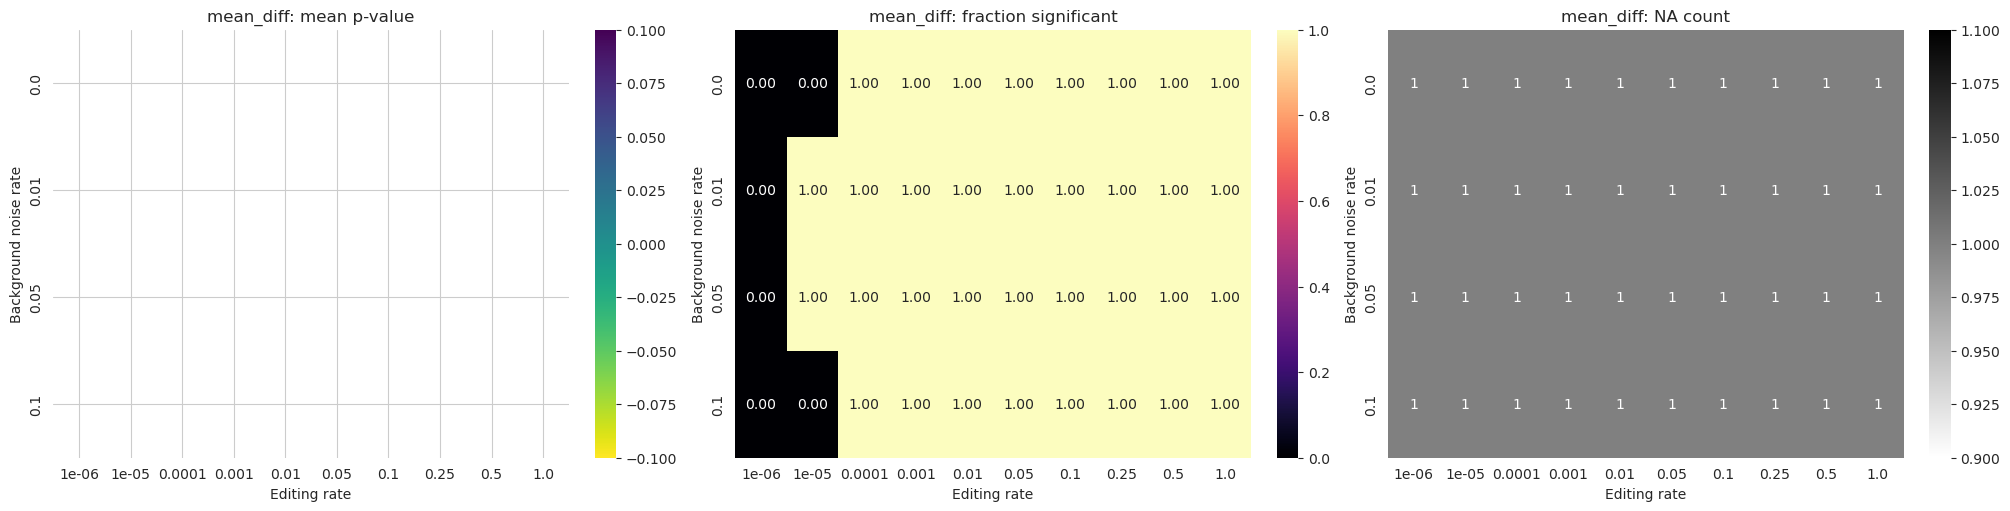

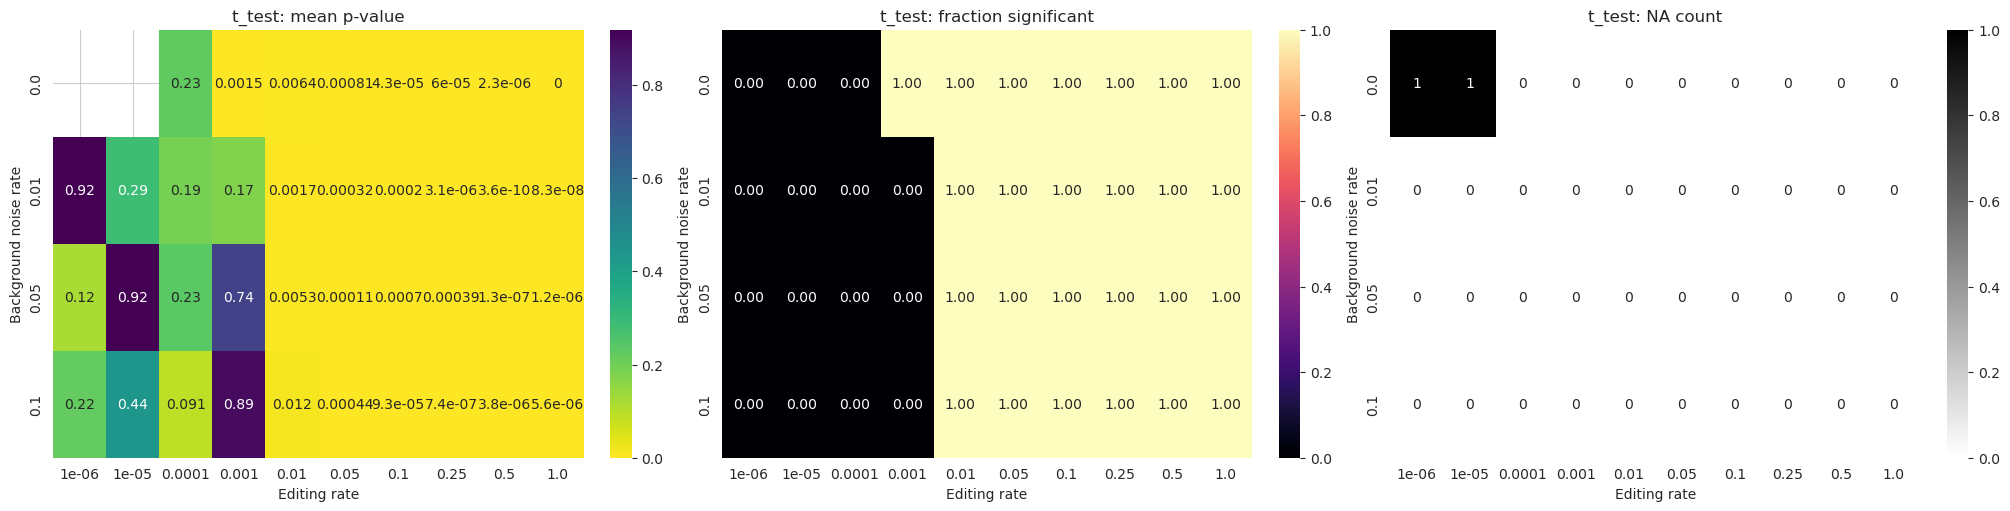

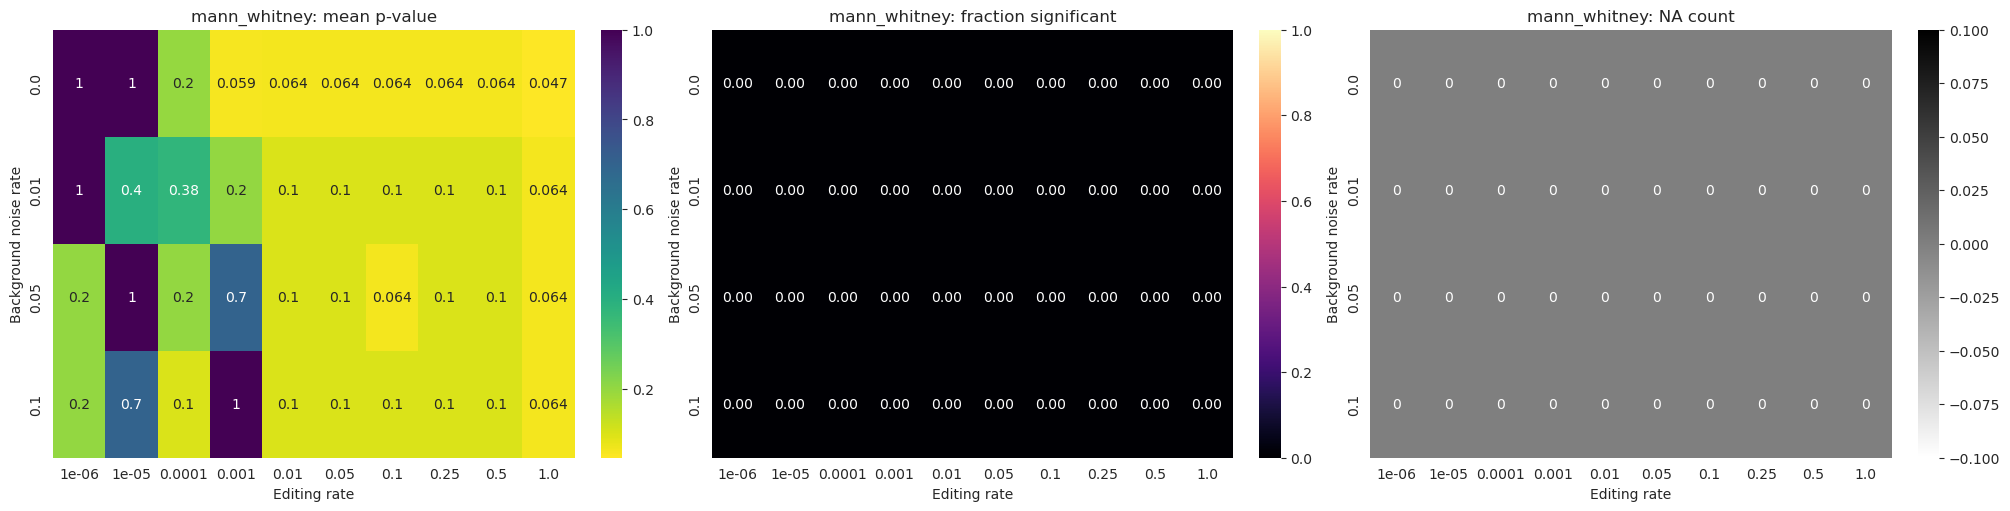

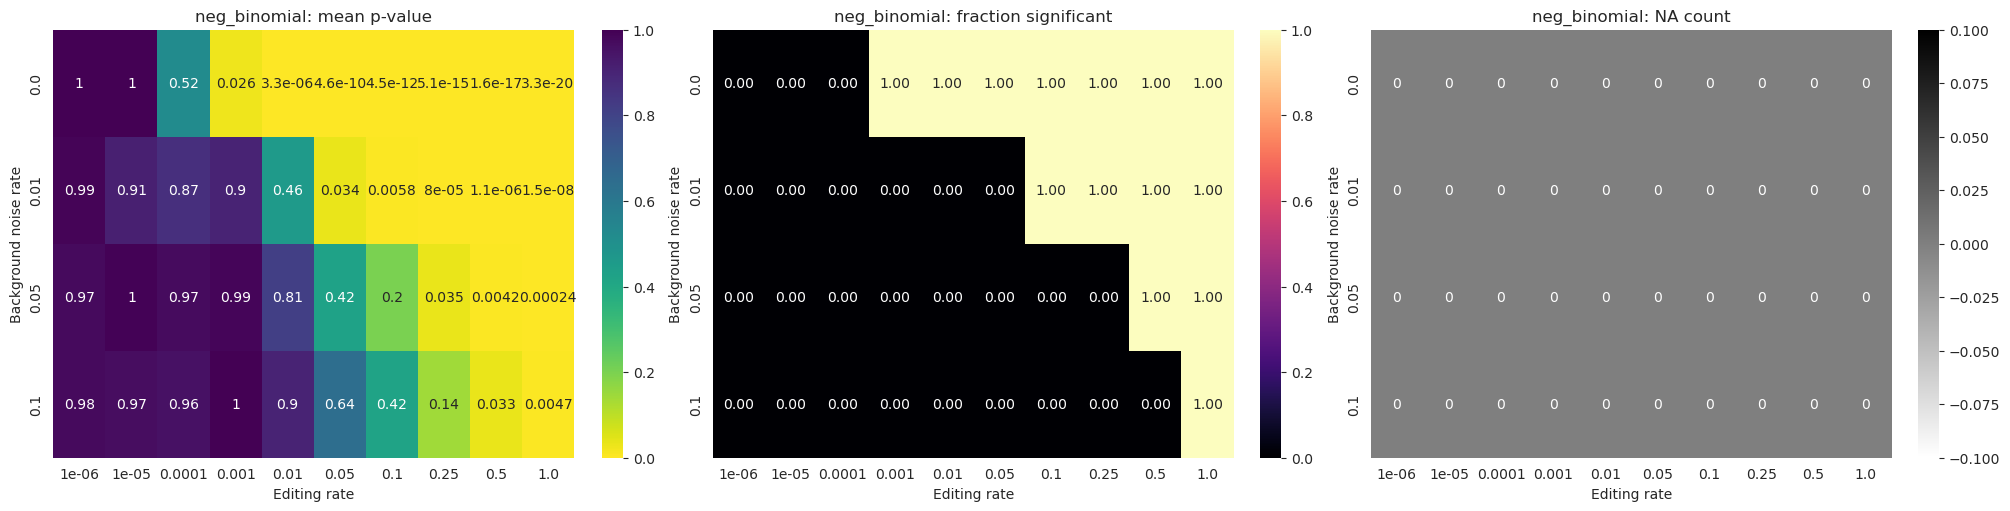

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

plot_order = ["hard_cutoff", "mean_diff", "t_test", "mann_whitney", "neg_binomial"]

for sig_test_name in plot_order:
    if sig_test_name not in sig_test_summary_tables:
        continue

    df = sig_test_summary_tables[sig_test_name].copy()
    df["background_noise_rate"] = pd.to_numeric(df["background_noise_rate"], errors="coerce")
    df["editing_rate"] = pd.to_numeric(df["editing_rate"], errors="coerce")

    if sig_test_name == "hard_cutoff":
        df["edited_significant_n"] = pd.to_numeric(df["edited_significant_n"], errors="coerce")
        df["unedited_significant_n"] = pd.to_numeric(df["unedited_significant_n"], errors="coerce")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

        edited_summary = (
            df.groupby(["background_noise_rate", "editing_rate"], as_index=False)["edited_significant_n"]
            .mean()
        )
        edited_pivot = edited_summary.pivot(
            index="background_noise_rate",
            columns="editing_rate",
            values="edited_significant_n",
        ).astype(float)

        unedited_summary = (
            df.groupby(["background_noise_rate", "editing_rate"], as_index=False)["unedited_significant_n"]
            .mean()
        )
        unedited_pivot = unedited_summary.pivot(
            index="background_noise_rate",
            columns="editing_rate",
            values="unedited_significant_n",
        ).astype(float)

        sns.heatmap(edited_pivot, cmap="Blues", ax=axes[0], annot=True, fmt=".2f")
        axes[0].set_title(f"Hard cutoff (>={hard_cutoff_pct:g}%): edited significant count")
        axes[0].set_xlabel("Editing rate")
        axes[0].set_ylabel("Background noise rate")

        sns.heatmap(unedited_pivot, cmap="Reds", ax=axes[1], annot=True, fmt=".2f")
        axes[1].set_title(f"Hard cutoff (>={hard_cutoff_pct:g}%): unedited significant count")
        axes[1].set_xlabel("Editing rate")
        axes[1].set_ylabel("Background noise rate")

        plt.show()

    else:
        df["pvalue"] = pd.to_numeric(df["pvalue"], errors="coerce")
        df["significant"] = pd.to_numeric(df["significant"], errors="coerce")
        df["is_na"] = df["pvalue"].isna().astype(float)

        fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

        pvalue_summary = (
            df.groupby(["background_noise_rate", "editing_rate"], as_index=False)["pvalue"]
            .mean()
        )
        pvalue_pivot = pvalue_summary.pivot(
            index="background_noise_rate",
            columns="editing_rate",
            values="pvalue",
        ).astype(float)

        significant_summary = (
            df.groupby(["background_noise_rate", "editing_rate"], as_index=False)["significant"]
            .mean()
        )
        significant_pivot = significant_summary.pivot(
            index="background_noise_rate",
            columns="editing_rate",
            values="significant",
        ).astype(float)

        na_summary = (
            df.groupby(["background_noise_rate", "editing_rate"], as_index=False)["is_na"]
            .sum()
        )
        na_pivot = na_summary.pivot(
            index="background_noise_rate",
            columns="editing_rate",
            values="is_na",
        ).astype(float)

        sns.heatmap(pvalue_pivot, cmap="viridis_r", ax=axes[0], annot=True, fmt=".2g")
        axes[0].set_title(f"{sig_test_name}: mean p-value")
        axes[0].set_xlabel("Editing rate")
        axes[0].set_ylabel("Background noise rate")

        sns.heatmap(
            significant_pivot,
            cmap="magma",
            vmin=0,
            vmax=1,
            ax=axes[1],
            annot=True,
            fmt=".2f",
        )
        axes[1].set_title(f"{sig_test_name}: fraction significant")
        axes[1].set_xlabel("Editing rate")
        axes[1].set_ylabel("Background noise rate")

        sns.heatmap(na_pivot, cmap="gray_r", ax=axes[2], annot=True, fmt=".0f")
        axes[2].set_title(f"{sig_test_name}: NA count")
        axes[2].set_xlabel("Editing rate")
        axes[2].set_ylabel("Background noise rate")

        plt.show()
